In [2]:
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer
import pandas as  pd
import numpy as np
analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe',
                                     'data/colors/munsell_colors/munsell_manifest.csv')
embeddings = analyzer.chain_loader.get_all_available_embeddings()

/Users/georgij/Documents/Работа/Color-MMLs/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# PCA анализ векторов эмбеддингов LLM декодера и vision энкодера мультимодальной большой языковой модели QWEN 2.5 7B

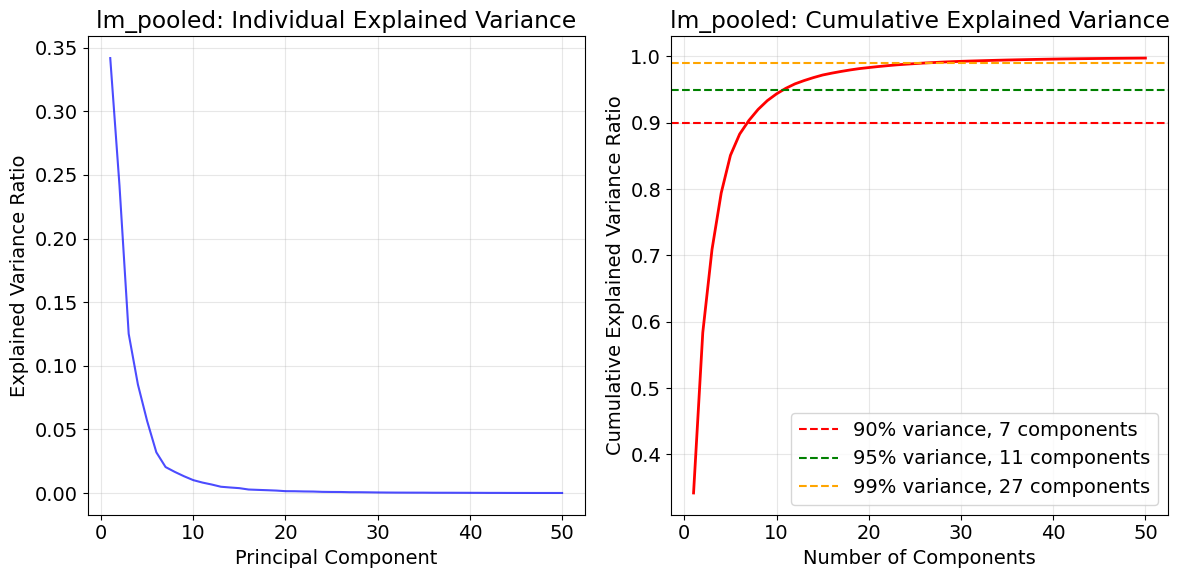

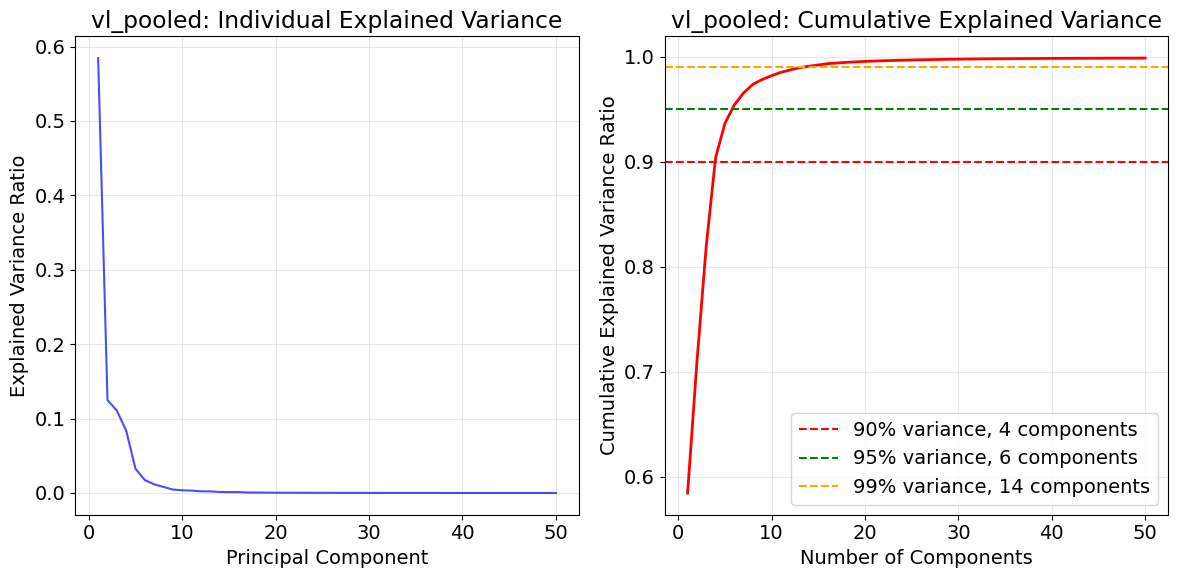

In [28]:
pca_result = analyzer.pca_by_embeddings(embeddings)

analyzer.plot_pca_variance(pca_result, embedding_name='lm_pooled')
analyzer.plot_pca_variance(pca_result, embedding_name='vl_pooled')

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression

def intrinsic_dimension_knn_regression(X, k=20):
    """
    Оценка ID методом k-NN регрессии (Slope of log-log plot).
    log(k) = d * log(R_k) + C
    """
    n = X.shape[0]
    # Те же предобработки: L2 нормализация
    X_norm = normalize(X, norm='l2')
    
    neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)
    neigh.fit(X_norm)
    dists, _ = neigh.kneighbors(X_norm)
    
    # Отбрасываем 0-го соседа (себя)
    dists = dists[:, 1:]
    
    # Массив рангов соседей: [1, 2, ..., k]
    ks = np.arange(1, k + 1)
    log_ks = np.log(ks).reshape(-1, 1) # X для регрессии (но мы поменяем местами для d)
    
    local_dims = []
    
    # Для каждой точки строим регрессию
    # Нам нужно d = slope(log(R), log(k))
    # Y = log(k), X = log(R) -> Y = d*X + C
    
    for i in range(n):
        # Берем расстояния для i-й точки
        r_vals = dists[i]
        
        # Защита от нулевых расстояний (дубликатов)
        r_vals = np.maximum(r_vals, 1e-10)
        
        log_r = np.log(r_vals).reshape(-1, 1)
        
        # Линейная регрессия
        model = LinearRegression()
        model.fit(log_r, log_ks) # fit(X, y)
        
        # Коэффициент наклона и есть размерность
        slope = model.coef_[0][0]
        local_dims.append(slope)
        
    return np.mean(local_dims), np.array(local_dims)

--- Сравнение методов (k=20) ---
k-NN Regression (LLM):     Mean = 2.347, Std = 0.832
k-NN Regression (VL):     Mean = 2.719, Std = 0.975
--- MLE (Levina-Bickel) ---
LLM: Mean = 2.831, Std = 1.011
VL: Mean = 3.079, Std = 0.960


/var/folders/4m/l3r2f5js3z959cxtw9_5q5pr0000gn/T/ipykernel_39267/1302147335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


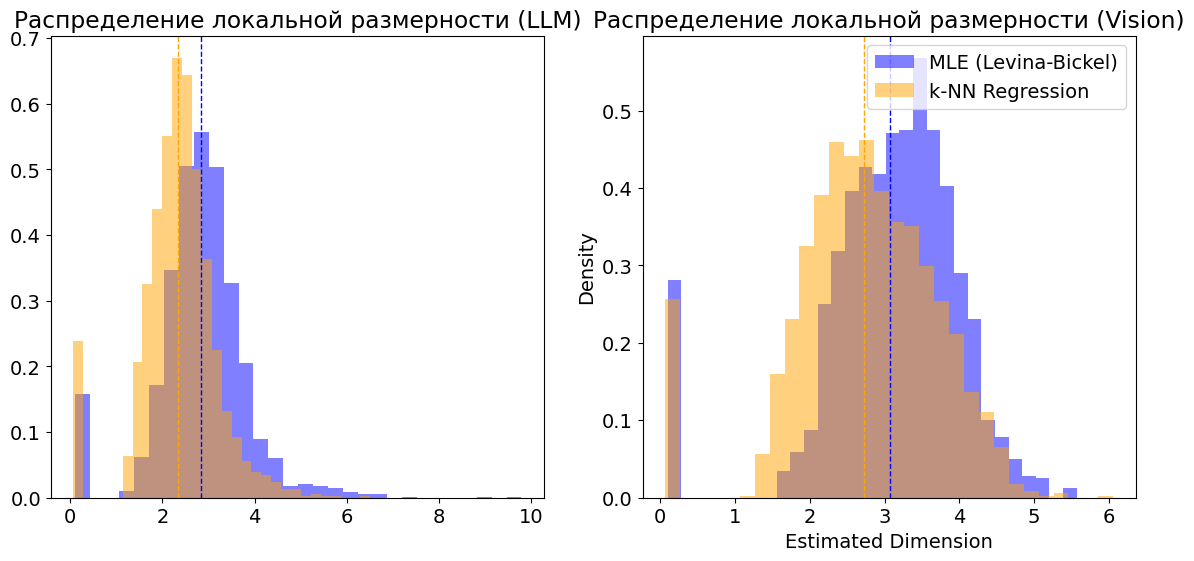

In [43]:

def intrinsic_dimension_mle_short(X, k=20):
    X_norm = normalize(X, norm='l2')
    neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)
    neigh.fit(X_norm)
    dists, _ = neigh.kneighbors(X_norm)
    dists = dists[:, 1:]
    T_k = dists[:, -1].reshape(-1, 1)
    T_j = dists[:, :-1]
    epsilon = 1e-10
    local_ids = (k - 2) / np.sum(np.log(np.maximum(T_k, epsilon) / np.maximum(T_j, epsilon)), axis=1)
    return np.mean(local_ids), local_ids

mean_mle_llm, vals_mle_llm = intrinsic_dimension_mle_short(embeddings['lm_pooled'], k=20)
mean_mle_vl, vals_mle_vl = intrinsic_dimension_mle_short(embeddings['vl_pooled'], k=20)

# 2. Запуск k-NN Regression на LLM и VL
mean_reg_llm, vals_reg_llm = intrinsic_dimension_knn_regression(embeddings['lm_pooled'], k=20)
mean_reg_vl, vals_reg_vl = intrinsic_dimension_knn_regression(embeddings['vl_pooled'], k=20)


print(f"--- Сравнение методов (k=20) ---")
print(f"k-NN Regression (LLM):     Mean = {mean_reg_llm:.3f}, Std = {np.std(vals_reg_llm):.3f}")
print(f"k-NN Regression (VL):     Mean = {mean_reg_vl:.3f}, Std = {np.std(vals_reg_vl):.3f}")
print(f"--- MLE (Levina-Bickel) ---")
print(f"LLM: Mean = {mean_mle_llm:.3f}, Std = {np.std(vals_mle_llm):.3f}")
print(f"VL: Mean = {mean_mle_vl:.3f}, Std = {np.std(vals_mle_vl):.3f}")

# Визуализация распределения оценок
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title('Распределение локальной размерности (LLM)')
axes[0].hist(vals_mle_llm, bins=30, alpha=0.5, label='MLE (Levina-Bickel)', color='blue', density=True)
axes[0].hist(vals_reg_llm, bins=30, alpha=0.5, label='k-NN Regression', color='orange', density=True)
axes[0].axvline(mean_mle_llm, color='blue', linestyle='dashed', linewidth=1)
axes[0].axvline(mean_reg_llm, color='orange', linestyle='dashed', linewidth=1)

axes[1].set_title('Распределение локальной размерности (Vision)')
axes[1].set_xlabel('Estimated Dimension')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].hist(vals_mle_vl, bins=30, alpha=0.5, label='MLE (Levina-Bickel)', color='blue', density=True)
axes[1].hist(vals_reg_vl, bins=30, alpha=0.5, label='k-NN Regression', color='orange', density=True)
axes[1].axvline(mean_mle_vl, color='blue', linestyle='dashed', linewidth=1)
axes[1].axvline(mean_reg_vl, color='orange', linestyle='dashed', linewidth=1)

plt.xlabel('Estimated Dimension')
plt.ylabel('Density')
plt.legend()
plt.show()


In [12]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

def intrinsic_dimension_mle(X, k=20):
    """
    Оценка внутренней размерности методом Levina-Bickel (MLE).
    
    Аргументы:
    X -- матрица данных (n_samples, n_features)
    k -- количество соседей для оценки (рекомендуется 10-20)
    
    Возвращает:
    float -- средняя оценка размерности
    numpy.array -- массив локальных размерностей для каждой точки
    """
    n = X.shape[0]
    
    # 1. Критически важно для эмбеддингов: L2 нормализация
    # Теперь все векторы имеют длину 1, и мы работаем на гиперсфере.
    X_norm = normalize(X, norm='l2')
    
    # 2. Поиск ближайших соседей
    # Используем 'euclidean' на нормализованных данных, что эквивалентно
    # ранжированию по косинусному расстоянию, но сохраняет линейность метрики для формулы.
    # Берем k+1, так как 0-й сосед - это сама точка (расстояние 0).
    neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)
    neigh.fit(X_norm)
    
    # dists: расстояния до соседей, indices: индексы соседей
    dists, _ = neigh.kneighbors(X_norm)
    
    # 3. Применяем формулу Levina-Bickel
    # Отбрасываем колонку 0 (расстояние до себя = 0)
    # dists[:, 1:] - это матрица расстояний от 1-го до k-го соседа
    dists = dists[:, 1:] 
    
    # T_k - это расстояние до k-го соседа (последний столбец)
    # Нам нужно, чтобы T_k было вектором-столбцом для бродкастинга
    T_k = dists[:, -1].reshape(-1, 1)
    
    # T_j - это расстояния до всех соседей от 1 до k-1
    # Срез [:, :-1] берет всех кроме последнего (k-го)
    T_j = dists[:, :-1]
    
    # Избегаем деления на ноль (если есть дубликаты точек)
    # Добавляем крошечный эпсилон, если T_j = 0
    epsilon = 1e-10
    T_k = np.maximum(T_k, epsilon)
    T_j = np.maximum(T_j, epsilon)
    
    # Сама формула:
    # d = [ (1 / (k-1)) * sum( log(T_k / T_j) ) ] ^ -1
    # log(T_k / T_j) = log(T_k) - log(T_j)
    
    log_sum = np.sum(np.log(T_k / T_j), axis=1)
    
    # k-1 в формуле, так как суммируем j от 1 до k-1
    local_ids = (k - 1) / log_sum
    
    return np.mean(local_ids), local_ids

LLM: Qwen2.5 7B - Munsell Colors Describe
Оценка внутренней размерности (MLE): 2.99
Разброс оценок (std): 1.07


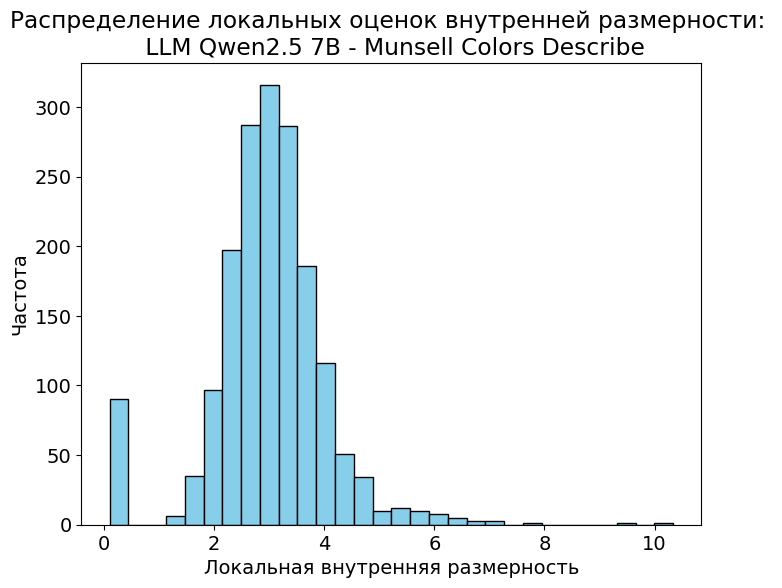

VL: Qwen2.5 7B - Munsell Colors Describe
Оценка внутренней размерности (MLE): 3.25
Разброс оценок (std): 1.01


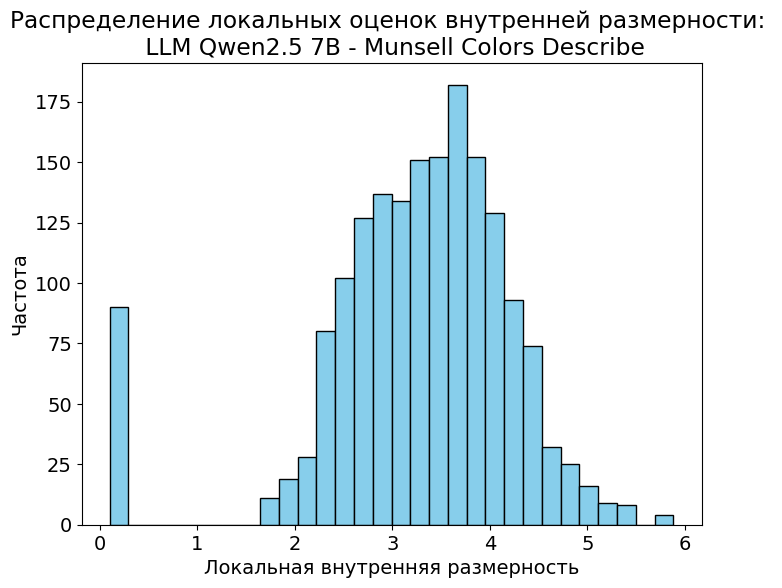

In [27]:
# Считаем размерность
mean_id, local_ids = intrinsic_dimension_mle(embeddings['lm_pooled'], k=20)

print("LLM: Qwen2.5 7B - Munsell Colors Describe")
print(f"Оценка внутренней размерности (MLE): {mean_id:.2f}")
print(f"Разброс оценок (std): {np.std(local_ids):.2f}")
# Можно также визуализировать распределение локальных размерностей:
import matplotlib.pyplot as plt
plt.hist(local_ids, bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение локальных оценок внутренней размерности: \n LLM Qwen2.5 7B - Munsell Colors Describe')
plt.xlabel('Локальная внутренняя размерность')
plt.ylabel('Частота')
plt.show()
mean_id, local_ids = intrinsic_dimension_mle(embeddings['vl_pooled'], k=20)

print("VL: Qwen2.5 7B - Munsell Colors Describe")
print(f"Оценка внутренней размерности (MLE): {mean_id:.2f}")
print(f"Разброс оценок (std): {np.std(local_ids):.2f}")
# Можно также визуализировать распределение локальных размерностей:
import matplotlib.pyplot as plt
plt.hist(local_ids, bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение локальных оценок внутренней размерности: \n LLM Qwen2.5 7B - Munsell Colors Describe')
plt.xlabel('Локальная внутренняя размерность')
plt.ylabel('Частота')
plt.show()
# Интерпретация для вашего случая:
# Если получите ~3.0 - 4.0 -> Цвета идеально сохранили структуру.
# Если ~6.0 - 9.0 -> Подтверждение вашего PCA (цвета зашумлены семантикой).

In [18]:
meta = pd.DataFrame(analyzer.chain_loader.get_all_available_colors())

In [22]:
meta

,csv_index,H,C,V,xyY,RGB,munsell_spec,embedding_index
0,1,2.5R,2,1,"(0.374, 0.292, 0.98)","(0.15180069899393897, 0.07594270536297584, 0.1...",2.5R 1/2,1
1,2,2.5R,4,1,"(0.431, 0.265, 0.83)","(0.17646414800794896, 0.037272441417358505, 0....",2.5R 1/4,2
2,3,2.5R,6,1,"(0.471, 0.242, 0.74)","(0.1928536502399172, 0.003754075775206642, 0.0...",2.5R 1/6,3
3,4,2.5R,0,2,"(0.31, 0.316, 3.12)","(0.19906676219935004, 0.19110852505243353, 0.2...",2.5R 2/0,4
4,5,2.5R,2,2,"(0.36, 0.3, 2.67)","(0.24191171455123356, 0.1529733338266698, 0.18...",2.5R 2/2,5
...,...,...,...,...,...,...,...,...
1749,1750,10.0RP,12,7,"(0.433, 0.264, 29.5)","(0.9757220017526754, 0.34684807776532744, 0.60...",10.0RP 7/12,1750
1750,1751,10.0RP,2,8,"(0.329, 0.309, 55.3)","(0.8729552669879507, 0.7312067224801058, 0.800...",10.0RP 8/2,1751
1751,1752,10.0RP,4,8,"(0.348, 0.302, 51.8)","(0.9254524851755507, 0.6786916622268728, 0.774...",10.0RP 8/4,1752
1752,1753,10.0RP,6,8,"(0.368, 0.294, 48.8)","(0.9774969186030281, 0.6236404099236474, 0.753...",10.0RP 8/6,1753


In [23]:
rgb = meta['RGB']

In [24]:
len(rgb)

1754

In [25]:
rgb

0       (0.15180069899393897, 0.07594270536297584, 0.1...
1       (0.17646414800794896, 0.037272441417358505, 0....
2       (0.1928536502399172, 0.003754075775206642, 0.0...
3       (0.19906676219935004, 0.19110852505243353, 0.2...
4       (0.24191171455123356, 0.1529733338266698, 0.18...
                              ...                        
1749    (0.9757220017526754, 0.34684807776532744, 0.60...
1750    (0.8729552669879507, 0.7312067224801058, 0.800...
1751    (0.9254524851755507, 0.6786916622268728, 0.774...
1752    (0.9774969186030281, 0.6236404099236474, 0.753...
1753    (0.9768200625442128, 0.8401810187268409, 0.910...
Name: RGB, Length: 1754, dtype: object

In [29]:
embeddings['lm_pooled']

array([[  9.31250000e+00,   7.71875000e+00,   3.06250000e+00, ...,
         -2.18750000e+00,   2.46875000e+00,   1.10156250e+00],
       [  6.46875000e+00,   6.43750000e+00,   3.33984375e-01, ...,
         -2.14062500e+00,   2.73437500e+00,   8.78906250e-01],
       [  5.96875000e+00,   6.03125000e+00,  -6.60156250e-01, ...,
         -1.60937500e+00,   2.67187500e+00,   5.27343750e-01],
       ..., 
       [  1.75781250e+00,   1.06250000e+01,  -1.39843750e+00, ...,
         -1.30859375e-01,  -3.21960449e-03,   3.43750000e+00],
       [  2.53125000e+00,   1.09375000e+01,  -1.20312500e+00, ...,
         -4.68750000e-01,   4.58984375e-01,   3.71875000e+00],
       [  4.15625000e+00,   9.75000000e+00,   8.94531250e-01, ...,
         -2.09375000e+00,   2.96875000e-01,   5.03125000e+00]], dtype=float32)

In [26]:
len(embeddings['lm_pooled'])

1755

Корреляция расстояний (Isomap 3D): 0.9656
Корреляция расстояний (PCA 3D):    0.9076


ValueError: 'c' argument has 1754 elements, which is inconsistent with 'x' and 'y' with size 1755.

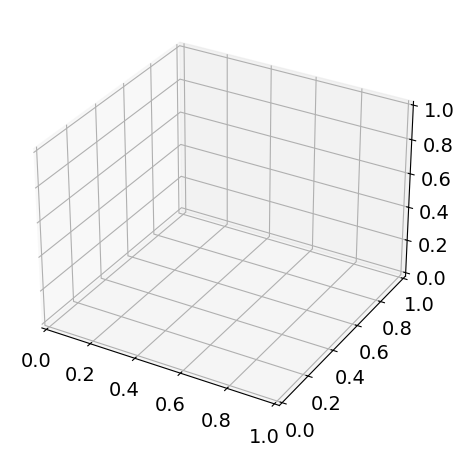

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# X - ваши данные (num_samples, 3400)
# 1. Нормализация (обязательно для эмбеддингов)
X_norm = normalize(embeddings['lm_pooled'], norm='l2')

# 2. Isomap: Попытка развернуть многообразие в 3D
# n_neighbors должно быть согласовано с тем k, где MLE давал стабильный результат (15-20)
iso = Isomap(n_neighbors=20, n_components=3)
X_iso = iso.fit_transform(X_norm)

# 3. PCA: Для сравнения (проекция на плоскость)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_norm)

# 4. Оценка качества: Reconstruction Error (Residual Variance)
# Насколько хорошо мы сохранили расстояния?
# Считаем корреляцию между расстояниями в 3400D (геодезическими) и 3D

from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

# Аппроксимация геодезических расстояний в исходном пространстве (через граф)
dist_geo_high = iso.dist_matrix_ # Isomap сам считает это внутри
# Берем только верхний треугольник матрицы, чтобы не дублировать
mask = np.triu_indices_from(dist_geo_high, k=1)

# Расстояния в полученном 3D пространстве
dist_iso_low = pairwise_distances(X_iso)
dist_pca_low = pairwise_distances(X_pca)

corr_iso, _ = pearsonr(dist_geo_high[mask], dist_iso_low[mask])
corr_pca, _ = pearsonr(dist_geo_high[mask], dist_pca_low[mask])

print(f"Корреляция расстояний (Isomap 3D): {corr_iso:.4f}")
print(f"Корреляция расстояний (PCA 3D):    {corr_pca:.4f}")

# Визуализация
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_iso[:, 0], X_iso[:, 1], X_iso[:, 2], c=rgb, s=5)
ax1.set_title(f'Isomap 3D (R={corr_iso:.2f})')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=rgb, s=5) # Красим так же для сравнения
ax2.set_title(f'PCA 3D (R={corr_pca:.2f})')

plt.show()

Корреляция расстояний (Isomap 3D): 0.8941
Корреляция расстояний (PCA 3D):    0.7945


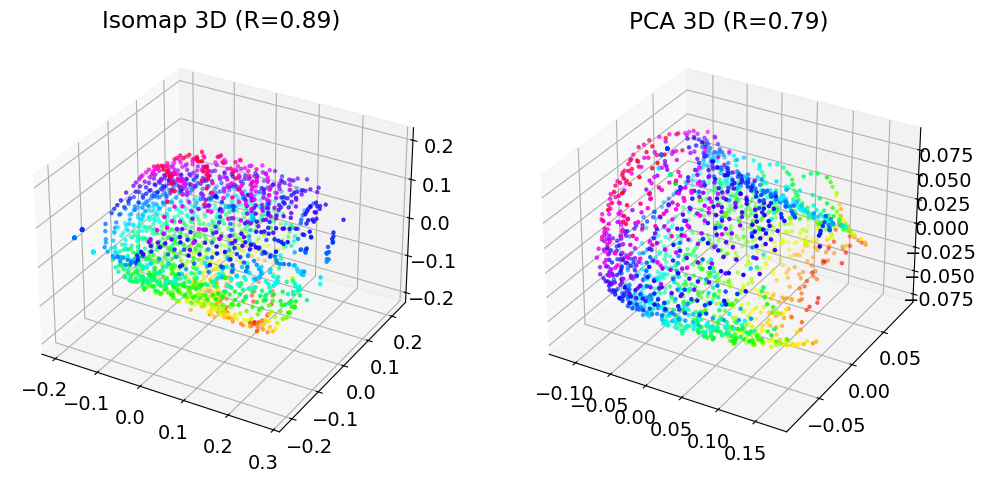

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# X - ваши данные (num_samples, 3400)
# 1. Нормализация (обязательно для эмбеддингов)
X_norm = normalize(embeddings['vl_pooled'], norm='l2')

# 2. Isomap: Попытка развернуть многообразие в 3D
# n_neighbors должно быть согласовано с тем k, где MLE давал стабильный результат (15-20)
iso = Isomap(n_neighbors=20, n_components=3)
X_iso = iso.fit_transform(X_norm)

# 3. PCA: Для сравнения (проекция на плоскость)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_norm)

# 4. Оценка качества: Reconstruction Error (Residual Variance)
# Насколько хорошо мы сохранили расстояния?
# Считаем корреляцию между расстояниями в 3400D (геодезическими) и 3D

from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

# Аппроксимация геодезических расстояний в исходном пространстве (через граф)
dist_geo_high = iso.dist_matrix_ # Isomap сам считает это внутри
# Берем только верхний треугольник матрицы, чтобы не дублировать
mask = np.triu_indices_from(dist_geo_high, k=1)

# Расстояния в полученном 3D пространстве
dist_iso_low = pairwise_distances(X_iso)
dist_pca_low = pairwise_distances(X_pca)

corr_iso, _ = pearsonr(dist_geo_high[mask], dist_iso_low[mask])
corr_pca, _ = pearsonr(dist_geo_high[mask], dist_pca_low[mask])

print(f"Корреляция расстояний (Isomap 3D): {corr_iso:.4f}")
print(f"Корреляция расстояний (PCA 3D):    {corr_pca:.4f}")

# Визуализация
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_iso[:, 0], X_iso[:, 1], X_iso[:, 2], c=X_iso[:, 2], cmap='hsv', s=5)
ax1.set_title(f'Isomap 3D (R={corr_iso:.2f})')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=X_iso[:, 2], cmap='hsv', s=5) # Красим так же для сравнения
ax2.set_title(f'PCA 3D (R={corr_pca:.2f})')

plt.show()

In [13]:
X_llm = embeddings['lm_pooled']
X_vl = embeddings['vl_pooled']

num_samples = X_llm.shape[0]

Mean Alignment Score (Cosine Sim): 0.0409
Min: 0.0189, Max: 0.0566


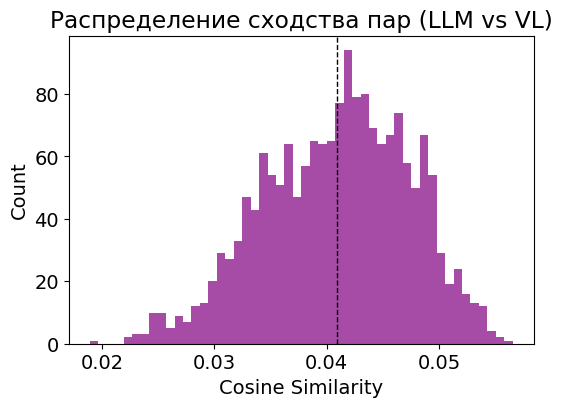

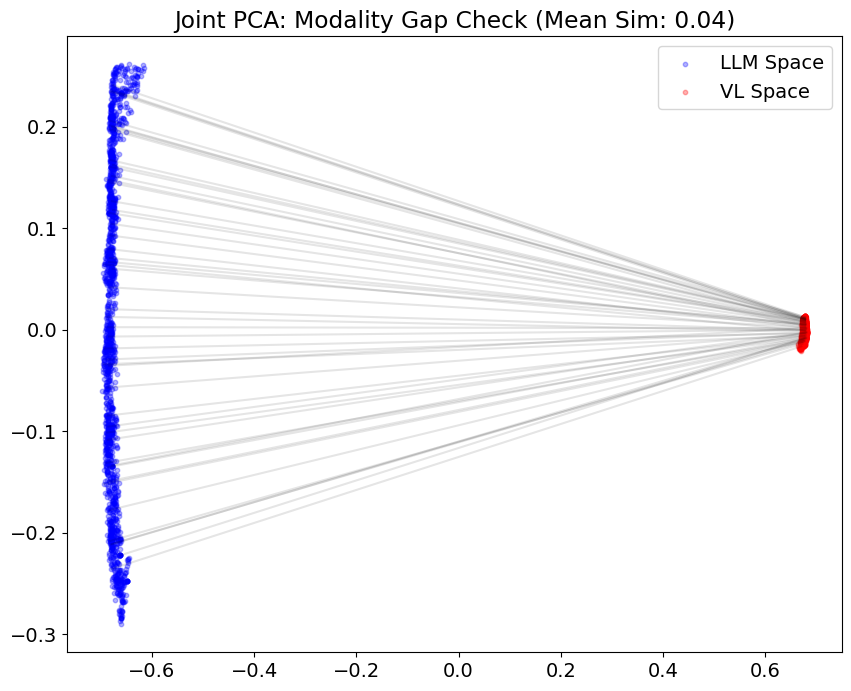

RSA Correlation (Pearson): 0.8133, p-value: 0.00e+00


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

# Предполагаем, что X_llm и X_vl - это матрицы (num_samples, 3400)
# И они УЖЕ в одном пространстве (после адаптера)

# 0. Нормализация (обязательно для косинусной метрики)
X_llm_norm = normalize(X_llm, norm='l2')
X_vl_norm = normalize(X_vl, norm='l2')

# --- СПОСОБ 1: Alignment (Direct Similarity) ---
# Считаем скалярное произведение для соответствующих пар (диагональ матрицы сходства)
# (a . b) для каждой строки
alignment_scores = np.sum(X_llm_norm * X_vl_norm, axis=1)

mean_alignment = np.mean(alignment_scores)
print(f"Mean Alignment Score (Cosine Sim): {mean_alignment:.4f}")
print(f"Min: {np.min(alignment_scores):.4f}, Max: {np.max(alignment_scores):.4f}")

# Гистограмма выравнивания
plt.figure(figsize=(6, 4))
plt.hist(alignment_scores, bins=50, color='purple', alpha=0.7)
plt.title('Распределение сходства пар (LLM vs VL)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.axvline(mean_alignment, color='k', linestyle='dashed', linewidth=1)
plt.show()

# --- СПОСОБ 2: Joint Visualization (Modality Gap) ---
# Объединяем данные
X_combined = np.vstack([X_llm_norm, X_vl_norm])
# Метки: 0 для LLM, 1 для VL
labels = np.array([0]*num_samples + [1]*num_samples)

# PCA для объединенных данных
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_combined)

plt.figure(figsize=(10, 8))
# Рисуем LLM точки (синие)
plt.scatter(X_pca_2d[:num_samples, 0], X_pca_2d[:num_samples, 1], 
            c='blue', alpha=0.3, label='LLM Space', s=10)
# Рисуем VL точки (красные)
plt.scatter(X_pca_2d[num_samples:, 0], X_pca_2d[num_samples:, 1], 
            c='red', alpha=0.3, label='VL Space', s=10)

# Рисуем линии между парами (для первых 50 точек, чтобы не засорять)
for i in range(50):
    plt.plot([X_pca_2d[i, 0], X_pca_2d[num_samples+i, 0]], 
             [X_pca_2d[i, 1], X_pca_2d[num_samples+i, 1]], 
             'k-', alpha=0.1)

plt.title(f'Joint PCA: Modality Gap Check (Mean Sim: {mean_alignment:.2f})')
plt.legend()
plt.show()

# --- СПОСОБ 3: Корреляция Пирсона для векторов (если нужны p-value) ---
# Мы можем взять векторы и посчитать корреляцию.
# Но так как они в одном пространстве, лучше использовать RSA (сравнение расстояний), 
# чтобы исключить влияние поворота (хотя адаптер должен был его убрать).

dists_llm = pdist(X_llm, metric='cosine')
dists_vl = pdist(X_vl, metric='cosine')

corr, p_value = pearsonr(dists_llm, dists_vl)
print(f"RSA Correlation (Pearson): {corr:.4f}, p-value: {p_value:.2e}")

# Если p-value < 0.05 - корреляция статистически значима.

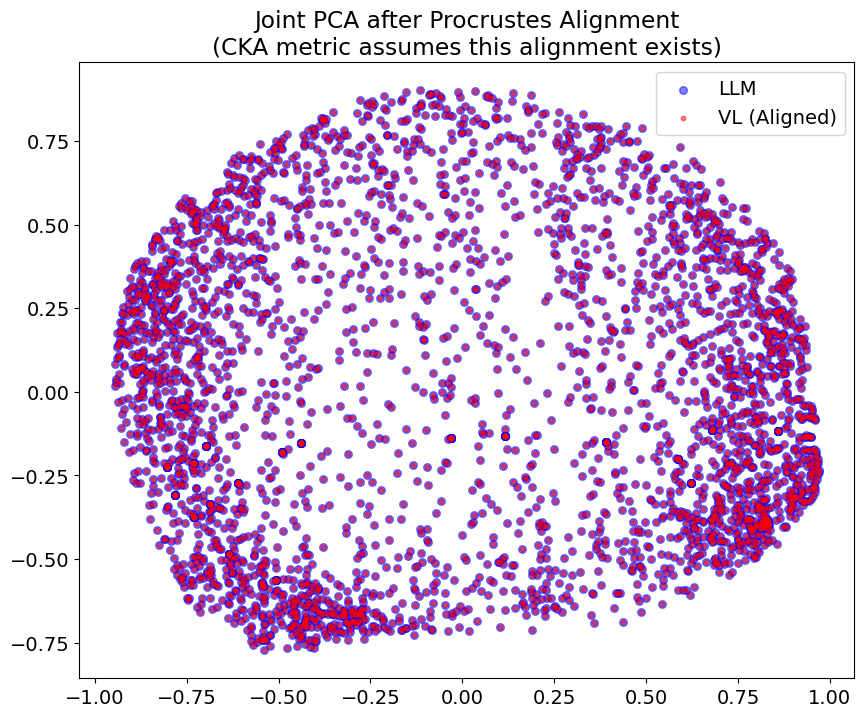

Истинные семантические выбросы (после поворота):


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from scipy.linalg import orthogonal_procrustes

# 1. Подготовка
# Центрирование (обязательно для Прокруста и PCA)
X_llm_centered = X_llm - np.mean(X_llm, axis=0)
X_vl_centered = X_vl - np.mean(X_vl, axis=0)

# Нормализация (L2), чтобы сравнивать направления, а не амплитуды
X_llm_norm = normalize(X_llm_centered, norm='l2')
X_vl_norm = normalize(X_vl_centered, norm='l2')

# 2. Прокрустово выравнивание (Orthogonal Procrustes)
# Находим матрицу поворота R, которая лучше всего накладывает VL на LLM
R, scale = orthogonal_procrustes(X_vl_norm, X_llm_norm)

# Применяем поворот к VL
X_vl_aligned = X_vl_norm @ R

# 3. Joint PCA на уже выровненных данных
X_combined = np.vstack([X_llm_norm, X_vl_aligned])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

X_pca_llm = X_pca
X_pca_vl = X_pca

# 4. Визуализация
plt.figure(figsize=(10, 8))

# Рисуем связи (ошибки выравнивания)
# Теперь длинные линии — это РЕАЛЬНЫЕ смысловые различия, а не просто поворот
for i in range(num_samples):
    # Рисуем только если ошибка заметная, чтобы не засорять график
    dist = np.linalg.norm(X_pca_llm[i] - X_pca_vl[i])
    if dist > 0.1: # Порог для визуализации "плохих" пар
        plt.plot([X_pca_llm[i, 0], X_pca_vl[i, 0]], 
                 [X_pca_llm[i, 1], X_pca_vl[i, 1]], 
                 color='red', alpha=0.1)

plt.scatter(X_pca_llm[:, 0], X_pca_llm[:, 1], c='blue', alpha=0.5, s=30, label='LLM')
plt.scatter(X_pca_vl[:, 0], X_pca_vl[:, 1], c='red', alpha=0.5, s=10, label='VL (Aligned)')

plt.title(f'Joint PCA after Procrustes Alignment\n(CKA metric assumes this alignment exists)')
plt.legend()
plt.show()

# 5. Поиск выбросов теперь будет честным
errors = np.linalg.norm(X_pca_llm - X_pca_vl, axis=1)
top_outliers = np.argsort(errors)[-10:]
print("Истинные семантические выбросы (после поворота):")
# Вывод имен...

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import normalize

def compare_models_rsa(X_llm, X_vl, metric='cosine'):
    """
    Сравнение моделей методом RSA (Representational Similarity Analysis).
    """
    # 1. Считаем попарные расстояния
    # metric='cosine' обычно лучше для эмбеддингов, но можно и 'euclidean'
    dists_llm = pairwise_distances(X_llm, metric=metric)
    dists_vl = pairwise_distances(X_vl, metric=metric)
    
    # 2. Берем верхний треугольник (без диагонали), чтобы не дублировать пары
    # k=1 означает исключить главную диагональ (расстояния до самих себя = 0)
    indices = np.triu_indices_from(dists_llm, k=1)
    
    vec_llm = dists_llm[indices]
    vec_vl = dists_vl[indices]
    
    # 3. Считаем корреляции
    # Пирсон: Линейная зависимость (если расстояния масштабированы линейно)
    r_pearson, p_pearson = pearsonr(vec_llm, vec_vl)
    
    # Спирмен: Ранговая зависимость (важно только "кто к кому ближе", а не абсолютные числа)
    # Спирмен часто надежнее для сравнения совершенно разных архитектур
    r_spearman, p_spearman = spearmanr(vec_llm, vec_vl)
    
    return r_pearson, r_spearman

def linear_cka(X, Y):
    """
    Линейный CKA (Centered Kernel Alignment).
    Более современный метод сравнения представлений нейросетей.
    """
    # Центрирование матриц Грома (Gram matrices)
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    
    gram_X = X @ X.T
    gram_Y = Y @ Y.T
    
    # Центрирование матриц ядра
    # (H = I - 1/n * J) -> K_c = H K H
    # Упрощенная формула для CKA:
    
    def centering(K):
        n = K.shape[0]
        unit = np.ones([n, n])
        I = np.eye(n)
        H = I - unit / n
        return H @ K @ H

    gram_X_c = centering(gram_X)
    gram_Y_c = centering(gram_Y)

    # Similarity
    numerator = np.trace(gram_X_c @ gram_Y_c)
    denominator = np.sqrt(np.trace(gram_X_c @ gram_X_c) * np.trace(gram_Y_c @ gram_Y_c))
    
    return numerator / denominator


# 1. RSA
pearson, spearman = compare_models_rsa(X_llm, X_vl, metric='cosine')

print(f"--- RSA Analysis ---")
print(f"Pearson correlation (Geometry): {pearson:.4f}")
print(f"Spearman correlation (Topology): {spearman:.4f}")

# 2. CKA
cka_score = linear_cka(X_llm, X_vl)
print(f"--- CKA Analysis ---")
print(f"Linear CKA Score: {cka_score:.4f}")

# Интерпретация:
# RSA Pearson > 0.8: Очень сильное сходство структур.
# RSA Spearman > Pearson: Значит модели согласны в рангах (ближе/дальше), 
#                         но используют разные масштабы расстояний.

--- RSA Analysis ---
Pearson correlation (Geometry): 0.8133
Spearman correlation (Topology): 0.8505
--- CKA Analysis ---
Linear CKA Score: 0.7655
